In [1]:
# !pip install matplotlib

In [3]:
import os
cwd = os.getcwd()
print(cwd)

d:\MsC\Thesis\Experiments\DIQKD\src


In [11]:
import numpy as np

def compute_CHSH(X, Y, A, B):

    N_eq_XY = np.zeros((4, 2))
    N_ne_XY = np.zeros((4, 2))

    for x_, y_, a_, b_ in zip(X, Y, A, B):
        x, y, a, b = int(x_), int(y_), int(a_), int(b_)

        if x < 2:
            continue

        if a == b:
            N_eq_XY[x, y] += 1
        else:
            N_ne_XY[x, y] += 1

    E_21 = N_ne_XY[2, 1] / (N_ne_XY[2, 1] + N_eq_XY[2, 1])
    E_20 = N_ne_XY[2, 0] / (N_ne_XY[2, 0] + N_eq_XY[2, 0])
    E_31 = N_ne_XY[3, 1] / (N_ne_XY[3, 1] + N_eq_XY[3, 1])
    E_30 = N_ne_XY[3, 0] / (N_ne_XY[3, 0] + N_eq_XY[3, 0])

    S = E_21 - E_20 - E_30 - E_31
    return S

In [10]:
import numpy as np

def compute_QBER(X, Y, A, B):

    N_XY = [0, 0]
    E_XY = [0, 0]

    for x_, y_, a_, b_ in zip(X, Y, A, B):
        x, y, a, b = int(x_), int(y_), int(a_), int(b_)

        if x != y or x > 1:
            continue
        
        error = a == b
        
        if x == 0:
            N_XY[0] += 1
            if error:
                E_XY[0] += 1
        
        elif x == 1:
            N_XY[1] += 1
            if error:
                E_XY[1] += 1

    Q_0 = float(E_XY[0]) / N_XY[0] if N_XY[0] > 0 else 0
    Q_1 = float(E_XY[1]) / N_XY[1] if N_XY[1] > 0 else 0
    Q = (Q_0 + Q_1) / 2
    
    return Q


# compute_QBER(
#     "..."
# )

In [4]:
from collections import defaultdict

chsh_values = defaultdict(list)
qber_values = defaultdict(list)

for x in range(101):
    filename = f"{os.getcwd()}/../data_defense/readout/{x:03d}.csv"
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                
                if not line or line.startswith("#"):
                    continue

                noise_str, chsh_str, qber_str, X, Y, A, B = line.split(",")
                
                noise = float(noise_str)
                chsh  = float(chsh_str)
                # chsh = compute_CHSH(X, Y, A, B)
                print(chsh)

                # qber = compute_QBER(X, Y, A, B)
                qber  = float(qber_str)
                print(qber)
                
                chsh_values[noise].append(chsh)
                qber_values[noise].append(qber)
                #break

    except FileNotFoundError:
        continue

    print(f"Noise {noise:.1f}%: {len(chsh_values[noise])} samples")
    #break
    
noises = sorted(chsh_values.keys())

2.57954
0.0751527
2.59368
0.0785665
2.574
0.0800909
2.58345
0.0769341
2.57802
0.0756997
2.60513
0.0770611
2.5781
0.0776271
2.60057
0.0761664
2.56121
0.0785818
2.55117
0.0777117
Noise 0.0%: 10 samples
2.47599
0.0946584
2.48603
0.0952462
2.46976
0.09865
2.46527
0.0973418
2.4626
0.0936616
2.45601
0.0944198
2.45243
0.0934561
2.49762
0.0958621
2.4975
0.0937617
2.45698
0.09509
Noise 1.0%: 10 samples
2.34203
0.109466
2.3993
0.110084
2.35391
0.109891
2.35984
0.109412
2.38736
0.113355
2.35802
0.11486
2.41643
0.11167
2.38641
0.108791
2.4251
0.112087
2.38362
0.110174
Noise 2.0%: 10 samples
2.28127
0.125386
2.29778
0.120755
2.24856
0.126562
2.25513
0.125497
2.27619
0.127739
2.2944
0.123715
2.26812
0.123978
2.31354
0.127832
2.282
0.125653
2.28727
0.128055
Noise 3.0%: 10 samples
2.1709
0.142113
2.18647
0.139231
2.17881
0.143299
2.17278
0.141578
2.1934
0.141693
2.16216
0.13792
2.18584
0.144883
2.16341
0.143747
2.21206
0.144219
2.19311
0.148757
Noise 4.0%: 10 samples
2.09973
0.157686
2.05983
0.160021


In [6]:
import numpy as np

chsh_mean = np.array([np.mean(chsh_values[n]) for n in noises])
chsh_std  = np.array([np.std(chsh_values[n], ddof=1) for n in noises])

qber_mean = np.array([np.mean(qber_values[n]) for n in noises])
qber_std  = np.array([np.std(qber_values[n], ddof=1) for n in noises])

#print(qber_values[0])

print("CHSH 0% noise", chsh_mean[0])
print("QBER 0% noise", qber_mean[0])

print("CHSH 50% noise", chsh_mean[50])
print("QBER 50% noise", qber_mean[50])

print("CHSH 100% noise", chsh_mean[100])
print("QBER 100% noise", qber_mean[100])

CHSH 0% noise 2.5804869999999998
QBER 0% noise 0.0773592
CHSH 50% noise -0.009984228999999999
QBER 50% noise 0.5000924999999999
CHSH 100% noise 2.579598
QBER 100% noise 0.07758155


In [8]:
for e in range(0, 101):
    filename = f'../data/readout/test_result_{e}.csv'

    with open(filename, 'r') as file:
        
        out_filename = f'../data/shifting/test_result_{e}.csv' + '.dat'
        print(out_filename)

        with open(out_filename, 'w') as out_file:
            for line in file:

                noise_str, _, _, X, Y, A, B = line.split(',')
                n_rounds = len(X)
                
                # CHSH
                ALICE_INPUT_COUNT = 4
                BOB_INPUT_COUNT = 2
                correlated_count = [[0 for _ in range(BOB_INPUT_COUNT)] for _ in range(ALICE_INPUT_COUNT)]
                anti_correlated_count = [[0 for _ in range(BOB_INPUT_COUNT)] for _ in range(ALICE_INPUT_COUNT)]

                alice_key = ''
                bob_key = ''

                # N_XY = [0, 0]
                # N_XY_err = [0, 0]
                
                for i in range(n_rounds):

                    x = int(X[i])
                    y = int(Y[i])
                    a = int(A[i])
                    b = int(B[i])

                    # key round
                    if x == 0 or x == 1:
                        # same input
                        if x == y:
                            alice_key += str(1 if a == 0 else 0)
                            bob_key += str(b)

                    # test round
                    else:
                        # correlated output
                        if a == b:
                            correlated_count[x][y] += 1
                        else:
                            anti_correlated_count[x][y] += 1

                    continue

                #print(correlated_count)
                #print(anti_correlated_count)
                
                E = [[0 for _ in range(BOB_INPUT_COUNT)] for _ in range(ALICE_INPUT_COUNT)]
                for i in range(2, 4):
                    for j in range(0, 2):
                        sum = correlated_count[i][j] + anti_correlated_count[i][j]
                        dif = correlated_count[i][j] - anti_correlated_count[i][j]
                        E[i][j] = float(dif) / sum

                #S = E[2][1] - E[2][0] - E[3][0] - E[3][1]
                qber = compute_QBER(X, Y, A, B)
                #print(e, qber)
                
                out_file.write(alice_key + ',' + bob_key +'\n')

../data/shifting/test_result_0.csv.dat
../data/shifting/test_result_1.csv.dat
../data/shifting/test_result_2.csv.dat
../data/shifting/test_result_3.csv.dat
../data/shifting/test_result_4.csv.dat
../data/shifting/test_result_5.csv.dat
../data/shifting/test_result_6.csv.dat
../data/shifting/test_result_7.csv.dat
../data/shifting/test_result_8.csv.dat
../data/shifting/test_result_9.csv.dat
../data/shifting/test_result_10.csv.dat
../data/shifting/test_result_11.csv.dat
../data/shifting/test_result_12.csv.dat
../data/shifting/test_result_13.csv.dat
../data/shifting/test_result_14.csv.dat
../data/shifting/test_result_15.csv.dat
../data/shifting/test_result_16.csv.dat
../data/shifting/test_result_17.csv.dat
../data/shifting/test_result_18.csv.dat
../data/shifting/test_result_19.csv.dat
../data/shifting/test_result_20.csv.dat
../data/shifting/test_result_21.csv.dat
../data/shifting/test_result_22.csv.dat
../data/shifting/test_result_23.csv.dat
../data/shifting/test_result_24.csv.dat
../data/sh

In [35]:
import numpy as np
from collections import defaultdict

L = np.zeros((101))
E = np.zeros((101, 5))

qber_cascade_values = defaultdict(list)

for noise in range(0, 101, 1):
    file_path = f'../data_defense/correction/{noise:03d}.csv'

    with open(file_path, 'r') as file:
        for line in file:
            parts = line.split(',')

            L[noise] += int(parts[0])

            round_id = 0
            for error in parts[1:]:

                E[noise, round_id] += int(error)
                round_id += 1

            qber_cascade = float(parts[-1]) / int(parts[0])
            qber_cascade_values[noise].append(qber_cascade)

# for noise in range(0, 101, 1):
#     #print(L[noise], E[noise])
#     print(qber_cascade_values[noise])

(101, 5)


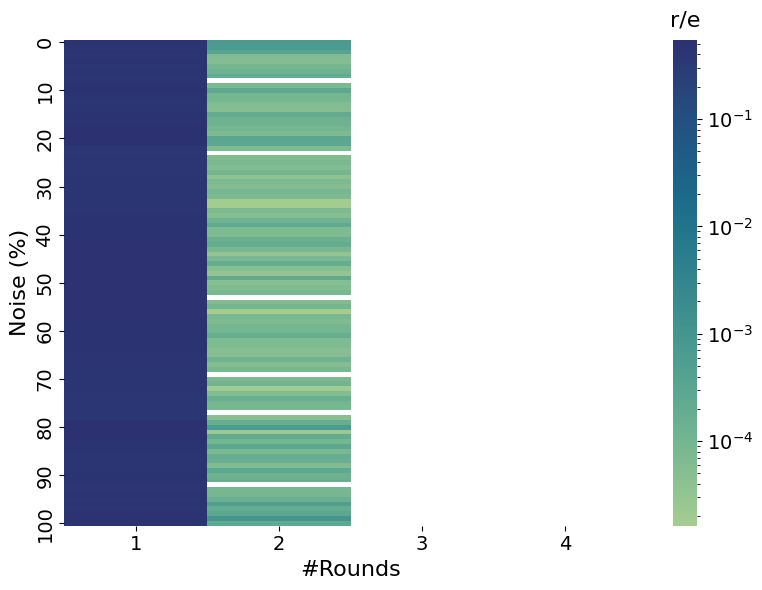

In [56]:
import numpy as np
from matplotlib.colors import LogNorm

e_values = np.arange(0, 101)
n_values = np.arange(1, 5)

ratio = E.astype(float) / E[:, [0]]
print(ratio.shape)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    ratio[:,1:],
    cmap='crest',
    norm=LogNorm(),
    vmin=0, vmax=1,
    xticklabels=n_values,
    yticklabels=10,
    annot=False, fmt=".2f",
    cbar_kws={}
)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_title('r/e', fontsize=16, pad=10)

plt.xlabel('#Rounds', fontsize=16)
plt.ylabel('Noise (%)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("../images/plot_noise_CASCADE_v3.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [10]:
qber_cascade_mean = np.array([np.mean(qber_cascade_values[n]) for n in noises])
qber_cascade_std  = np.array([np.std(qber_cascade_values[n], ddof=1) for n in noises])

print("qber_cascade_mean", qber_cascade_mean)
print("qber_mean", qber_mean)

improvement = (qber_mean - qber_cascade_mean) * 100
print("Improvement (%)", np.average(improvement))
print("Improvement per noise level", improvement)


qber_cascade_mean [0.00000000e+00 0.00000000e+00 0.00000000e+00 9.55261901e-05
 7.91045366e-06 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 8.01314155e-06 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 8.81269027e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.93556323e-06
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.000

C:\Users\Human\AppData\Local\Temp\ipykernel_40304\234024667.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=12)
C:\Users\Human\AppData\Local\Temp\ipykernel_40304\234024667.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend().set_visible(False)


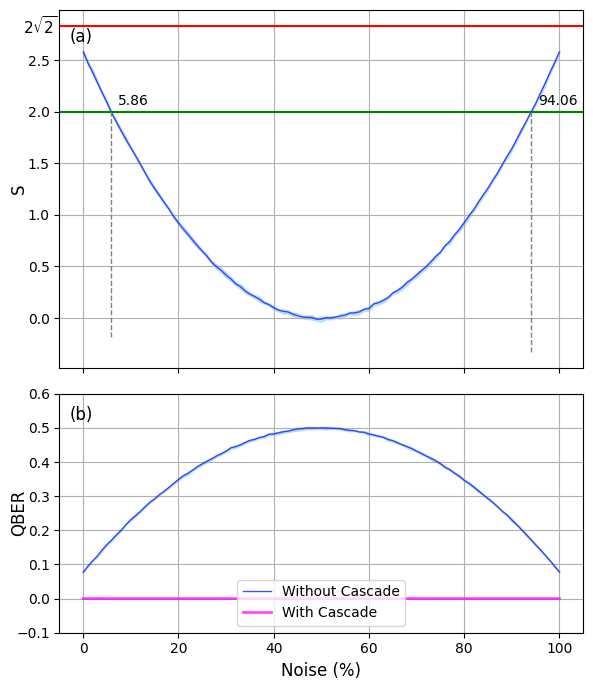

In [11]:
import numpy as np  
import matplotlib.pyplot as plt
import math

import matplotlib.pyplot as plt
import math

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), gridspec_kw={'height_ratios': [3, 2]})

ax1.fill_between(
    noises,
    chsh_mean - chsh_std,
    chsh_mean + chsh_std,
    color='skyblue',
    alpha=0.5
)

ideal_chsh = 2 * math.sqrt(2)

ax1.plot(noises, chsh_mean, color='blue', linewidth=1, alpha=0.7)
ax1.axhline(y=2.0, color='g', linestyle='-')
ax1.axhline(y=ideal_chsh, color='r', linestyle='-')

ax1.annotate(r'$2\sqrt{2}$',
            xy=(0, ideal_chsh),
            xytext=(-1, 0),
            xycoords=('axes fraction', 'data'),
            textcoords='offset points',
            ha='right', va='center',
            fontsize=11)

target = 2.0

# indices where sign changes → crossings
idxs = np.where(np.diff(np.sign(chsh_mean - target)))[0]
x_crossings = []

for idx in idxs:
    x0, x1 = noises[idx], noises[idx+1]
    y0, y1 = chsh_mean[idx], chsh_mean[idx+1]

    # linear interpolation
    x_cross = x0 + (target - y0) * (x1 - x0) / (y1 - y0)
    x_crossings.append(x_cross)

for x_cross in x_crossings:
    ax1.vlines(x_cross,
              ymin=ax1.get_ylim()[0],
              ymax=target,
              colors='gray',
              linestyles='dashed',
              linewidth=1)

    ax1.annotate(f'{x_cross:.2f}',
                xy=(x_cross, target),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=10,
                color='black',
                )

#ax1.set_xlabel("Noise (%)", fontsize=12)
ax1.set_ylabel("S", fontsize=12)
ax1.text(
    0.02, 0.95, '(a)',
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment='top'
)

ax2.set_xlim(-5, 105)
ax2.set_ylim(-0.5, 3)
ax1.grid(True)
ax1.legend(fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)
ax1.legend().set_visible(False)

# ----------------------------------------------------------------

# --- Q ---
ax2.fill_between(
    noises,
    qber_mean - qber_std,
    qber_mean + qber_std,
    color='skyblue',
    alpha=0.5
)

ax2.plot(
    noises,
    qber_mean,
    color='blue',
    linewidth=1,
    alpha=0.7,
    label='Without Cascade'
)

# --- Q_Cascade (same axis) ---
ax2.fill_between(
    noises,
    qber_cascade_mean - qber_cascade_std,
    qber_cascade_mean + qber_cascade_std,
    color='magenta',
    alpha=0.3
)

ax2.plot(
    noises,
    qber_cascade_mean,
    color='magenta',
    linewidth=2,
    alpha=0.7,
    label='With Cascade',
)

# --- Labels & styling ---
ax2.set_xlabel("Noise (%)", fontsize=12)
ax2.set_ylabel("QBER", fontsize=12)
ax2.set_xlim(-5, 105)
ax2.set_ylim(-0.1, 0.6)
ax2.grid(True)
ax2.text(
    0.02, 0.95, '(b)',
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment='top'
)

# --- Single legend ---
ax2.legend(loc='lower center', fontsize=10)

ax1.yaxis.set_label_coords(-0.06, 0.5)
ax2.yaxis.set_label_coords(-0.06, 0.5)

plt.tight_layout()
plt.savefig("../images/plot_noise_CHSH_QBER_Cascade_v2.pdf", format="pdf", bbox_inches="tight")
plt.show()